# Goal

Use word frequencies to identify who wrote a document, treating text as data rather than reading it for meaning

### Questions?

1. Are two books by the same author more similar to each other than to a book by a different author?
1. Are there words one author prefers and the other avoids?

### Data source

Project Gutenberg plain-text files:
    Austen: Pride and Prejudice (1342), Emma (158)
    Twain: Adventures of Huckleberry Finn (76), Tom Sawyer (74)

Processing steps:
    Strip the Gutenberg license boilerplate
    Remove HTML markup and punctuation
    Tokenize on whitespace
    Count with Counter, converting to relative frequency (count / total words) so books of different length are comparable

### Comparisons

Within author: Austen vs. Austen, Twain vs. Twain
Between authors: Austen vs. Twain

Two views per book:
    Content words (stopwords removed) — shows topic
    Function words (stopwords kept) — shows style

## 0. Setup

Only standard course libraries are used (`requests`, `pandas`, `numpy`, `matplotlib`). Each book is described by its author, its Project Gutenberg id, and the first words of Chapter 1, which are used to find where the story actually starts.

In [1]:
import math
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display

%matplotlib inline
pd.set_option("display.width", 140)

# title -> (author, Project Gutenberg id, first words of Chapter 1)
BOOKS = {
    "Pride and Prejudice": ("Austen", 1342, "It is a truth universally acknowledged"),
    "Emma":                ("Austen", 158,  "Emma Woodhouse, handsome, clever, and rich"),
    "Huckleberry Finn":    ("Twain",  76,   "You don't know about me without you have read a book"),
    "Tom Sawyer":          ("Twain",  74,   "TOM! No answer. TOM! No answer."),
}
TITLES = list(BOOKS)
AUTHOR = {t: BOOKS[t][0] for t in TITLES}
AUSTEN = [t for t in TITLES if AUTHOR[t] == "Austen"]
TWAIN = [t for t in TITLES if AUTHOR[t] == "Twain"]
COLOR = {"Austen": "#7b3294", "Twain": "#e08214"}
SHORT = {"Pride and Prejudice": "Pride & Prejudice", "Emma": "Emma",
         "Huckleberry Finn": "Huck Finn", "Tom Sawyer": "Tom Sawyer"}

## 1. Get the text

Each book is saved as `pg<id>.txt` the first time it is downloaded and read from disk after that. If Project Gutenberg is blocked from the container, download the `.txt` files on a laptop and copy them next to this notebook with the same names (as suggested in the course notebook).

In [2]:
def load_gutenberg(book_id):
    """Return the text of pg<id>.txt, downloading it from Project Gutenberg if it isn't here yet."""
    path = Path(f"pg{book_id}.txt")
    if not path.exists():
        url = f"https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt"
        response = requests.get(url, headers={"User-Agent": "Mozilla/5.0 (UTK course project)"}, timeout=60)
        response.raise_for_status()
        path.write_bytes(response.content)
    return path.read_text(encoding="utf-8-sig", errors="replace")


raw = {t: load_gutenberg(BOOKS[t][1]) for t in TITLES}
for t in TITLES:
    print(f"{t:20s} {len(raw[t]):>9,} characters")

Pride and Prejudice    704,189 characters
Emma                   902,387 characters
Huckleberry Finn       593,959 characters
Tom Sawyer             412,716 characters


## 2. Clean and tokenize

The processing steps from the plan, plus fixes for problems that showed up while inspecting the files:

1. **Strip the Gutenberg license boilerplate** (the `*** START OF ...` and `*** END OF ...` markers).
2. **Skip everything before Chapter 1.** The boilerplate markers are not enough: the current *Pride and Prejudice* file includes a long preface by the critic George Saintsbury (a different writer!) and a list of illustration captions, and the Twain files open with a table of contents full of chapter summaries. The code finds the novel's first sentence and starts there.
3. **Remove HTML markup, `[Illustration]` captions, and `CHAPTER XII` heading lines** (so Roman numerals don't inflate the count of "i").
4. **Remove punctuation, but keep apostrophes inside words.** Deleting apostrophes silently turns *he'll* into *hell* and *it's* into *its* (see the check below). Curly apostrophes (’) are converted to straight ones first.
5. **Lowercase and tokenize on whitespace.**

In [3]:
START = re.compile(r"\*\*\*\s*START OF (?:THE|THIS) PROJECT GUTENBERG EBOOK[^\n]*", re.I)
END = re.compile(r"^\s*(?:\*\*\*\s*END OF (?:THE|THIS) PROJECT GUTENBERG EBOOK|End of (?:the )?Project Gutenberg)",
                 re.I | re.M)


def strip_to_story(text, first_words):
    """Remove the license text and all front matter; return (story text, times the opening was found)."""
    start = START.search(text)
    if start:
        text = text[start.end():]
    end = END.search(text)
    if end:
        text = text[:end.start()]
    # Match the opening words while ignoring case, punctuation, quote style, and line breaks.
    pattern = r"\W+".join(re.findall(r"\w+", first_words))
    hits = list(re.finditer(pattern, text, re.I))
    if not hits:
        raise ValueError(f"Could not find the opening words {first_words!r}")
    # If a preface quotes the first line, prefer the copy that sits right under a CHAPTER heading.
    under_heading = [h for h in hits if re.search(r"chapter", text[max(0, h.start() - 300):h.start()], re.I)]
    first = (under_heading or hits)[0]
    return text[text.rfind("\n", 0, first.start()) + 1:], len(hits)


ILLUSTRATION = re.compile(r"\[Illustration[^\]]*\]", re.I)
HTML_TAG = re.compile(r"<[^>]+>")
HEADING = re.compile(r"^\s*(?:chapter|volume)\s+[0-9ivxlc]+\.?\s*$", re.I | re.M)


def tokenize(text):
    text = ILLUSTRATION.sub(" ", text)                     # captions from illustrated editions
    text = HTML_TAG.sub(" ", text)                         # HTML markup
    text = HEADING.sub(" ", text)                          # "CHAPTER XII" lines
    text = text.lower().replace("\u2019", "'").replace("\u2018", "'")
    text = re.sub(r"[^a-z']+", " ", text)                  # punctuation, digits, dashes, underscores
    text = re.sub(r"(?<![a-z])'|'(?![a-z])", " ", text)    # quote marks go; don't / i'll / o'clock stay
    return text.split()                                    # tokenize on whitespace


story, tokens, rows = {}, {}, []
for t in TITLES:
    story[t], found = strip_to_story(raw[t], BOOKS[t][2])
    tokens[t] = tokenize(story[t])
    rows.append({"book": t, "author": AUTHOR[t], "words": len(tokens[t]),
                 "distinct words": len(set(tokens[t])), "opening found (times)": found,
                 "first words": " ".join(tokens[t][:7]), "last words": " ".join(tokens[t][-5:])})
pd.DataFrame(rows).set_index("book")

,author,words,distinct words,opening found (times),first words,last words
book,,,,,,
Pride and Prejudice,Austen,122074,6344,1,it is a truth universally acknowledged that,the means of uniting them
Emma,Austen,160874,7180,1,emma woodhouse handsome clever and rich with,happiness of the union finis
Huckleberry Finn,Twain,111856,6197,1,you don't know about me without you,end yours truly huck finn
Tom Sawyer,Twain,71052,7332,1,tom no answer tom no answer what's,of their lives at present


The *first words* and *last words* columns confirm that each book starts at Chapter 1 and ends at the author's last line rather than in license text. The check below shows why apostrophes had to stay: in *Huckleberry Finn*, deleting them would add dozens of fake uses of words like *hell* and *its*.

In [4]:
huck = Counter(tokens["Huckleberry Finn"])
pd.DataFrame([{"contraction": a, "uses": huck[a], "without apostrophe becomes": b, "real uses of that word": huck[b]}
              for a, b in [("he'll", "hell"), ("it's", "its"), ("we'll", "well"), ("i'll", "ill")]])

,contraction,uses,without apostrophe becomes,real uses of that word
0,he'll,30,hell,2
1,it's,217,its,17
2,we'll,40,well,417
3,i'll,120,ill,0


## 3. Count words and convert to relative frequency

**Function words (stopwords).** I wrote the list out explicitly instead of using `nltk.corpus.stopwords`. NLTK's English list contains *should* but not *would, could, must, shall, may, might,* or *upon*, which are classic markers of writing style. The list covers articles, pronouns, auxiliary and modal verbs, conjunctions, prepositions, common adverbs, and contractions (spelled with apostrophes to match the tokenizer).

**Capitalized words.** Character names turned out to be a major confound for content words. A word is treated as a name if it is capitalized at least 90% of the time it appears (e.g., *Elizabeth, Darcy, Huck, London, Mr, Mrs*). This list is used only for the robustness checks.

**Relative frequency** = count / total words in the book, so the 71,000-word *Tom Sawyer* can be compared with the 160,000-word *Emma*.

In [5]:
FUNCTION_WORDS = set("""
a an the this that these those
i me my mine myself we us our ours ourselves you your yours yourself yourselves
he him his himself she her hers herself it its itself they them their theirs themselves
one who whom whose which what whatever whoever
am is are was were be been being have has had having do does did doing
will would shall should can could may might must ought
and but or nor so yet if then than because as though although while whether unless till until since
of at by for with about against between into through during before after above below
to from up down in out on off over under upon among around across along without within toward towards
not no only very too just also again ever never here there where when why how now even still else
all any both each few more most other some such own same much many every either neither
i'm i've i'll i'd you're you've you'll you'd he's he'll he'd she's she'll she'd it's it'll
we're we've we'll we'd they're they've they'll they'd that's there's what's who's let's
isn't aren't wasn't weren't hasn't haven't hadn't don't doesn't didn't won't wouldn't
shan't shouldn't can't couldn't mustn't mightn't needn't ain't
""".split())


def capitalized_words(texts, threshold=0.9, min_count=5):
    """Words written with a capital letter at least 90% of the time: names, places, titles."""
    seen, capital = Counter(), Counter()
    for text in texts:
        for word in re.findall(r"[A-Za-z]+(?:['\u2019][A-Za-z]+)*", text):
            if word.isupper() and len(word) > 1:          # skip ALL-CAPS headings and shouting
                continue
            key = word.lower().replace("\u2019", "'")
            seen[key] += 1
            capital[key] += word[0].isupper()
    return {w for w, n in seen.items()
            if n >= min_count and capital[w] / n >= threshold and w not in FUNCTION_WORDS}


NAMES = capitalized_words(story.values())
counts = {t: Counter(tokens[t]) for t in TITLES}
total = {t: len(tokens[t]) for t in TITLES}

# The two views from the plan, plus two robustness checks. Each view is a rule for which words to keep.
VIEWS = {
    "content (stopwords removed)": lambda w: w not in FUNCTION_WORDS,
    "all words (stopwords kept)":  lambda w: True,
    "content, names removed":      lambda w: w not in FUNCTION_WORDS and w not in NAMES,
    "function words only":         lambda w: w in FUNCTION_WORDS,
}


def profile(counter, n_words, keep):
    """Relative frequency (count / total words) of every word the view keeps."""
    return {w: c / n_words for w, c in counter.items() if keep(w)}


def show(word):
    """Mask a racial slur that is frequent in Huckleberry Finn. It stays in the counts; it is only hidden in output."""
    return re.sub(r"^nigg\w*", "n-word", word)


print(f"{len(FUNCTION_WORDS)} function words, {len(NAMES)} capitalized words (e.g. {', '.join(sorted(NAMES)[:8])} ...)")
for t in TITLES:
    share = sum(c for w, c in counts[t].items() if w in FUNCTION_WORDS) / total[t]
    print(f"{t:20s} function words are {share:.0%} of all words")

211 function words, 296 capitalized words (e.g. abbey, abner, ah, alfred, amy, anne, arkansaw, avenger ...)
Pride and Prejudice  function words are 59% of all words
Emma                 function words are 59% of all words
Huckleberry Finn     function words are 58% of all words
Tom Sawyer           function words are 54% of all words


### Most frequent words in each book

The two views from the plan. Bar length is uses per 10,000 words.

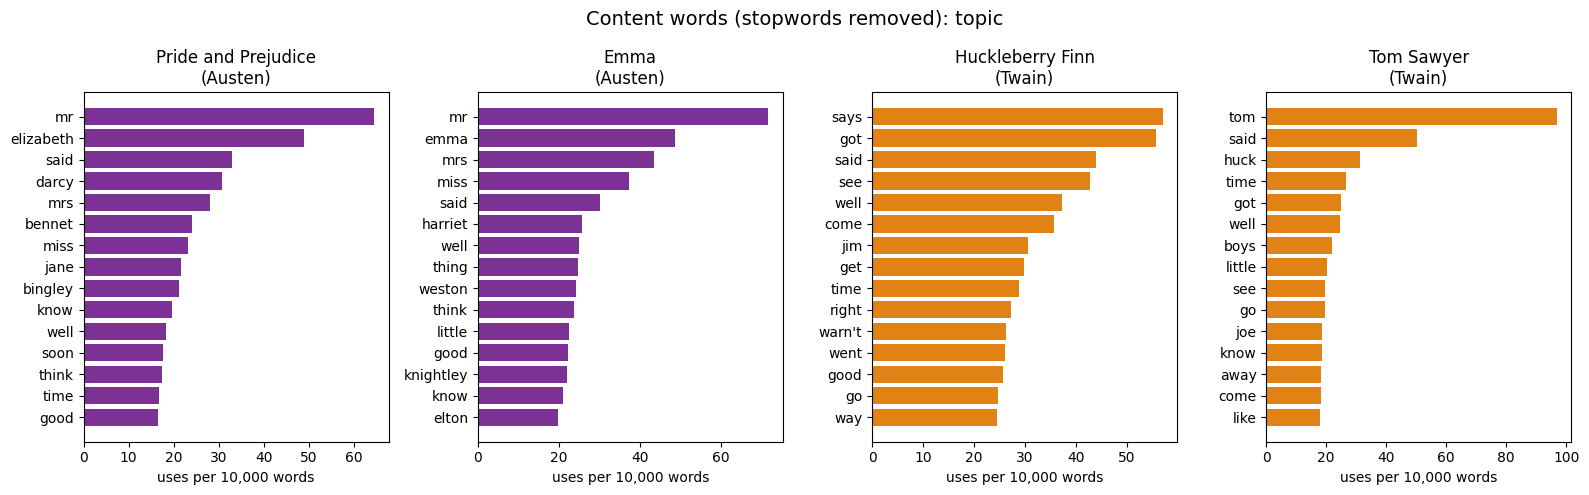

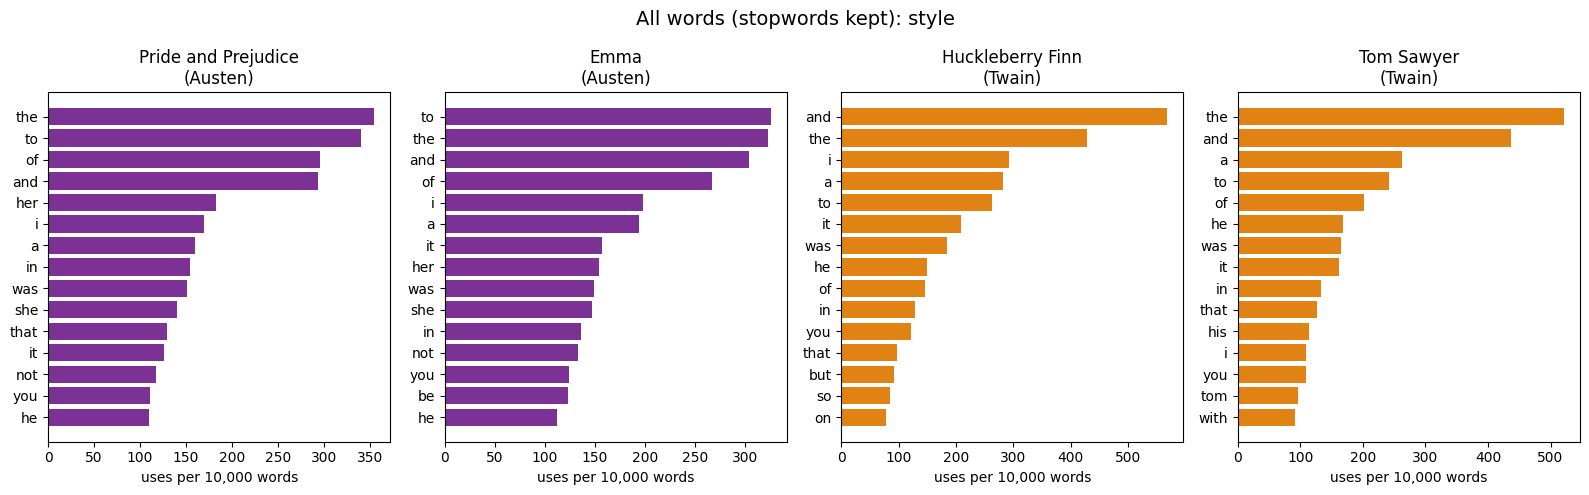

In [6]:
def plot_top_words(view_name, title, n=15):
    keep = VIEWS[view_name]
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for ax, t in zip(axes, TITLES):
        top = sorted(profile(counts[t], total[t], keep).items(), key=lambda kv: kv[1], reverse=True)[:n][::-1]
        ax.barh([show(w) for w, _ in top], [f * 10_000 for _, f in top], color=COLOR[AUTHOR[t]])
        ax.set_title(f"{t}\n({AUTHOR[t]})")
        ax.set_xlabel("uses per 10,000 words")
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()


plot_top_words("content (stopwords removed)", "Content words (stopwords removed): topic")
plot_top_words("all words (stopwords kept)", "All words (stopwords kept): style")

Even before computing anything, the lists hint at the answer. Austen's content words are forms of address (*mr, mrs, miss*) and heroine names; Twain's include colloquial and dialect forms (*got, says, warn't*). With stopwords kept, *her* and *she* rank high for Austen, while *and* tops *Huckleberry Finn* (Huck strings clauses together with "and... and...").

## Q1. Are two books by the same author more similar to each other than to a book by a different author?

Each book becomes a vector of relative frequencies (one entry per word). Two books are compared with **cosine similarity**: 1 means identical proportions, 0 means no words in common. The diagonal (a book compared with itself) is greyed out so the color scale shows the interesting pairs.

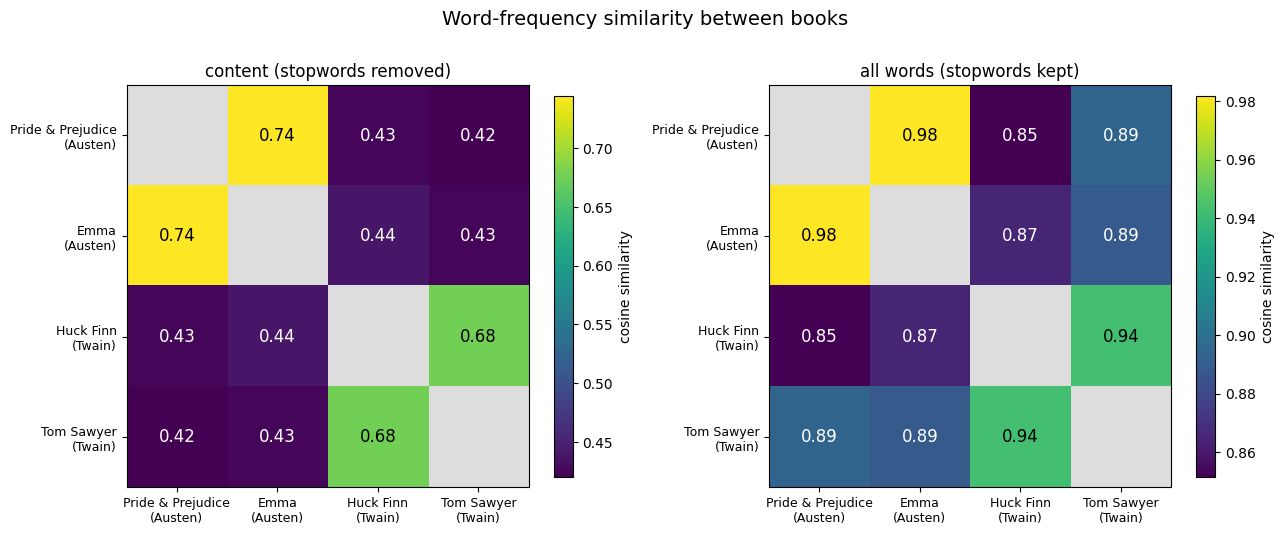

In [7]:
def unit(p):
    """Scale a {word: frequency} vector to length 1."""
    length = math.sqrt(sum(f * f for f in p.values()))
    return {w: f / length for w, f in p.items()}


def cosine(a, b):
    a, b = unit(a), unit(b)
    return sum(f * b[w] for w, f in a.items() if w in b)


def similarity_matrix(view_name):
    keep = VIEWS[view_name]
    vectors = {t: profile(counts[t], total[t], keep) for t in TITLES}
    return pd.DataFrame([[cosine(vectors[a], vectors[b]) for b in TITLES] for a in TITLES],
                        index=TITLES, columns=TITLES)


SIM = {name: similarity_matrix(name) for name in VIEWS}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, name in zip(axes, ["content (stopwords removed)", "all words (stopwords kept)"]):
    M = SIM[name].values
    off_diagonal = M[~np.eye(4, dtype=bool)]
    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad("#dddddd")
    im = ax.imshow(np.ma.masked_where(np.eye(4, dtype=bool), M), cmap=cmap,
                   vmin=off_diagonal.min(), vmax=off_diagonal.max())
    labels = [f"{SHORT[t]}\n({AUTHOR[t]})" for t in TITLES]
    ax.set_xticks(range(4))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticks(range(4))
    ax.set_yticklabels(labels, fontsize=9)
    middle = (off_diagonal.min() + off_diagonal.max()) / 2
    for i in range(4):
        for j in range(4):
            if i != j:
                ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=12,
                        color="white" if M[i, j] < middle else "black")
    ax.set_title(name)
    fig.colorbar(im, ax=ax, shrink=0.8, label="cosine similarity")
fig.suptitle("Word-frequency similarity between books", fontsize=14)
fig.tight_layout()
plt.show()

In [8]:
rows = []
for name, M in SIM.items():
    between = [M.loc[a, b] for a in AUSTEN for b in TWAIN]
    nearest_same_author = sum(AUTHOR[M.loc[t].drop(t).idxmax()] == AUTHOR[t] for t in TITLES)
    rows.append({"view": name,
                 "Austen vs Austen": round(M.loc["Pride and Prejudice", "Emma"], 3),
                 "Twain vs Twain": round(M.loc["Huckleberry Finn", "Tom Sawyer"], 3),
                 "Austen vs Twain (lowest-highest)": f"{min(between):.3f} - {max(between):.3f}",
                 "books whose closest match has the same author": f"{nearest_same_author} of 4"})
pd.DataFrame(rows).set_index("view")

,Austen vs Austen,Twain vs Twain,Austen vs Twain (lowest-highest),books whose closest match has the same author
view,,,,
content (stopwords removed),0.745,0.676,0.420 - 0.440,4 of 4
all words (stopwords kept),0.982,0.943,0.852 - 0.894,4 of 4
"content, names removed",0.904,0.778,0.561 - 0.701,4 of 4
function words only,0.991,0.953,0.866 - 0.910,4 of 4


**Answer: yes, in every view.** Each book's closest match is the other book by the same author.

- **Content words:** the two Austen novels score about 0.74 and the two Twain novels about 0.68, while every Austen-Twain pair is only about 0.42-0.44.
- **All words (style):** all numbers are high, because every English text is dominated by *the, and, to, of*. The ordering still holds: about 0.98 (Austen-Austen) and 0.94 (Twain-Twain) versus 0.85-0.89 across authors.
- **Is it just character names?** No. With capitalized words removed, the within-author pairs are still clearly the most similar (the absolute numbers rise because a few very frequent names no longer dominate the vectors). Function words alone give the same ordering.
- **A surprise:** in the style view *Tom Sawyer* is closer to both Austen novels than *Huckleberry Finn* is. *Huck Finn* is narrated in the first person in dialect, while *Tom Sawyer* has a third-person narrator like Austen's. Narrative voice shifts the fingerprint, which is a warning for attributing texts written in different voices.

## Q2. Are there words one author prefers and the other avoids?

Comparing pooled rates alone is misleading: *Elizabeth* is "preferred" by Austen only because she is a character in one book. So a word counts as a **consistent preference** only if:

- **both** books of one author use it at least **twice** as often as **either** book of the other author, and
- it appears at least once per 10,000 words in **each** of the preferring author's books.

Words are ranked by log2(Austen rate / Twain rate). A value of +3 means Austen uses the word 2³ = 8 times as often; −3 means Twain does. A count of 1 is added before taking the ratio so that words one author never uses don't cause division by zero. Content words are shown with names removed.

In [9]:
count_table = pd.DataFrame(counts).fillna(0)[TITLES]            # rows = words, columns = books
rate = count_table / pd.Series(total) * 10_000                 # uses per 10,000 words


def pooled(books):
    return count_table[books].sum(axis=1), sum(total[b] for b in books)


(austen_count, austen_n), (twain_count, twain_n) = pooled(AUSTEN), pooled(TWAIN)
pref = pd.DataFrame(index=count_table.index)
pref["log2 ratio"] = np.log2(((austen_count + 1) / austen_n) / ((twain_count + 1) / twain_n))
pref["never used by other author"] = (austen_count == 0) | (twain_count == 0)
austen_low, austen_high = rate[AUSTEN].min(axis=1), rate[AUSTEN].max(axis=1)
twain_low, twain_high = rate[TWAIN].min(axis=1), rate[TWAIN].max(axis=1)
pref["preferred by"] = np.select(
    [(austen_low >= 2 * twain_high) & (austen_low >= 1), (twain_low >= 2 * austen_high) & (twain_low >= 1)],
    ["Austen", "Twain"], default="")

is_function = pd.Series(pref.index.isin(FUNCTION_WORDS), index=pref.index)
is_name = pd.Series(pref.index.isin(NAMES), index=pref.index)
WORD_GROUPS = {"function words": is_function, "content words (names removed)": ~is_function & ~is_name}


def top_preferences(group, n=10):
    subset = pref[WORD_GROUPS[group]]
    austen = subset[subset["preferred by"] == "Austen"].sort_values("log2 ratio", ascending=False).head(n)
    twain = subset[subset["preferred by"] == "Twain"].sort_values("log2 ratio").head(n)
    return pd.concat([austen, twain])


for group in WORD_GROUPS:
    subset = pref[WORD_GROUPS[group]]
    n_austen = (subset["preferred by"] == "Austen").sum()
    n_twain = (subset["preferred by"] == "Twain").sum()
    print(f"{group}: {n_austen} consistent Austen preferences, {n_twain} consistent Twain preferences")

function words: 32 consistent Austen preferences, 41 consistent Twain preferences
content words (names removed): 255 consistent Austen preferences, 188 consistent Twain preferences


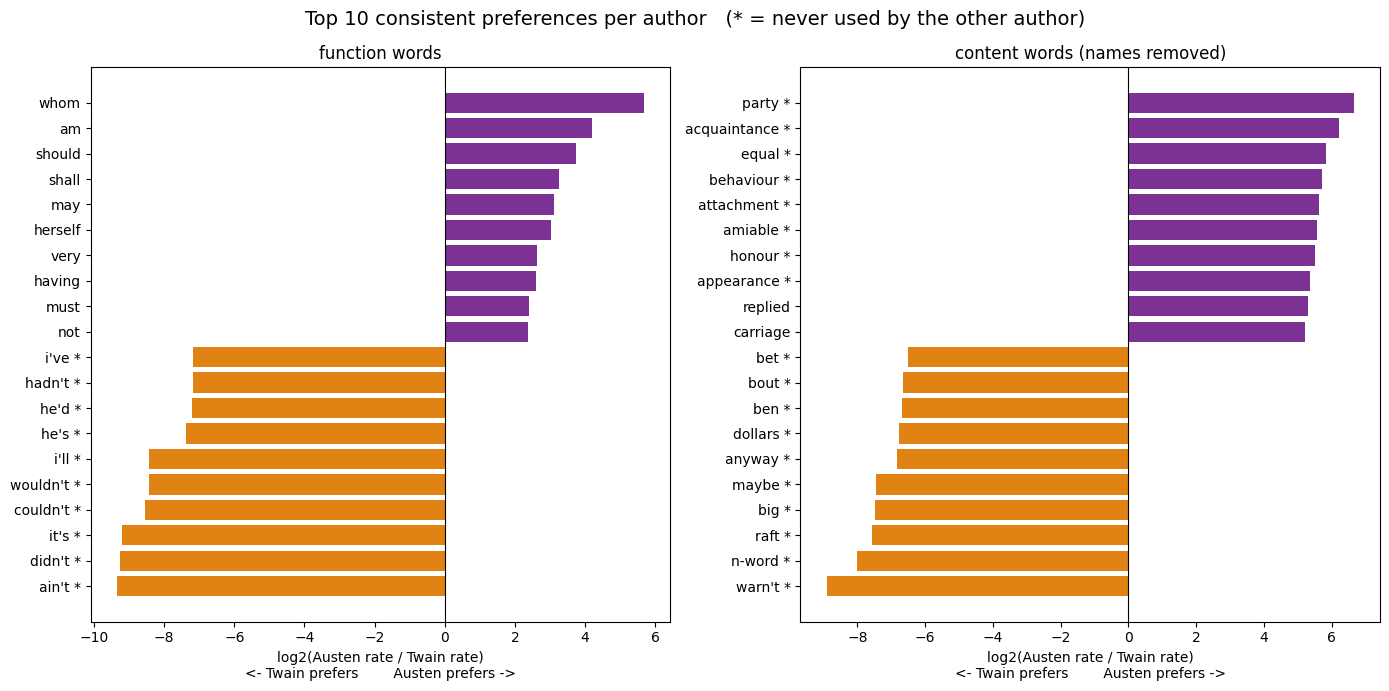

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, group in zip(axes, WORD_GROUPS):
    top = top_preferences(group).sort_values("log2 ratio")
    labels = [show(w) + (" *" if never else "") for w, never in zip(top.index, top["never used by other author"])]
    ax.barh(labels, top["log2 ratio"],
            color=[COLOR["Austen"] if v > 0 else COLOR["Twain"] for v in top["log2 ratio"]])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(group)
    ax.set_xlabel("log2(Austen rate / Twain rate)\n<- Twain prefers        Austen prefers ->")
fig.suptitle("Top 10 consistent preferences per author   (* = never used by the other author)", fontsize=14)
fig.tight_layout()
plt.show()

The same words with their per-book rates (uses per 10,000 words), so the consistency across both books is visible:

In [11]:
for group in WORD_GROUPS:
    table = rate.loc[top_preferences(group).index, TITLES].round(1)
    table.insert(0, "preferred by", pref.loc[table.index, "preferred by"])
    table.index = [show(w) for w in table.index]
    print(group.upper())
    display(table)

twain_plain = pref[is_function & (pref["preferred by"] == "Twain") & ~pref.index.str.contains("'")]
print("Function words Twain prefers that are NOT contractions:",
      ", ".join(twain_plain.sort_values("log2 ratio").index))

FUNCTION WORDS


,preferred by,Pride and Prejudice,Emma,Huckleberry Finn,Tom Sawyer
whom,Austen,6.9,4.5,0.0,0.1
am,Austen,26.0,25.7,1.4,1.3
should,Austen,20.3,23.1,0.4,3.4
shall,Austen,13.3,13.6,0.4,2.8
may,Austen,15.8,13.9,1.8,1.4
herself,Austen,18.6,17.3,1.6,3.0
very,Austen,39.9,75.3,8.9,11.0
having,Austen,7.9,9.1,1.3,1.4
must,Austen,25.2,35.5,5.7,5.9
not,Austen,117.1,133.7,14.5,40.0


CONTENT WORDS (NAMES REMOVED)


,preferred by,Pride and Prejudice,Emma,Huckleberry Finn,Tom Sawyer
party,Austen,4.7,6.0,0.0,0.0
acquaintance,Austen,4.3,3.9,0.0,0.0
equal,Austen,2.5,3.5,0.0,0.0
behaviour,Austen,4.5,1.6,0.0,0.0
attachment,Austen,2.2,3.0,0.0,0.0
amiable,Austen,2.9,2.2,0.0,0.0
honour,Austen,3.4,1.7,0.0,0.0
appearance,Austen,2.7,1.9,0.0,0.0
replied,Austen,8.4,4.9,0.0,0.3
carriage,Austen,3.6,4.3,0.0,0.1


Function words Twain prefers that are NOT contractions: around, along, below, down, up, out, why, then, off, over


### Same meaning, different author

A few pairs I picked by hand after reading the lists above. Each pair expresses roughly the same idea, and each author reliably uses one word of the pair.

In [12]:
PAIRS = [("perhaps", "maybe"), ("cannot", "can't"), ("suppose", "reckon"), ("very", "mighty")]
rows = []
for austen_word, twain_word in PAIRS:
    for word in (austen_word, twain_word):
        rows.append({"pair": f"{austen_word} / {twain_word}", "word": word, **rate.loc[word, TITLES].round(1)})
pd.DataFrame(rows).set_index(["pair", "word"])

Pride and Prejudice  Emma  Huckleberry Finn  Tom Sawyer
pair             word                                                            
perhaps / maybe  perhaps                  6.2   6.2               0.1         1.3
                 maybe                    0.0   0.0               6.2         6.1
cannot / can't   cannot                   9.2   8.8               0.0         0.6
                 can't                    0.2   0.1               8.7         7.0
suppose / reckon suppose                  3.9   5.0               0.1         0.4
                 reckon                   0.1   0.1              10.9        10.3
very / mighty    very                    39.9  75.3               8.9        11.0
                 mighty                   0.0   0.1               6.5         3.7

**Answer: yes, and the strongest differences are in function words.**

- **Austen prefers** *whom, am, should, shall, may, herself, very, must, not, will, her*: formal grammar, obligation and possibility, and female subjects. She almost never contracts. She writes *cannot* about 9 times per 10,000 words, and the two Austen novels contain essentially no *didn't, it's* or *ain't*.
- **Twain prefers** contractions (*ain't, didn't, it's, couldn't, I'll*). His non-contracted preferences are movement and place words (*around, along, down, up, out, off, over*), which fits adventure stories.
- **Content words** mix three kinds of signal. Some are topic (*raft, dollars* against *party, carriage*). Some are register (*acquaintance, amiable, attachment*). Some are dialect and colloquial speech (*warn't, 'bout, bet, anyway*); *warn't* is really a function word ("wasn't") that no stopword list recognizes. British spellings (*behaviour, honour*) also appear, so an edition's spelling conventions can look like an author preference.

## Does it actually identify the author of an unseen passage?

Q1 compared whole books. The real goal is to identify *who wrote a document*, so here is a harder test:

1. Cut every book into passages of a fixed length.
2. Compare each passage with the **other three** whole books. Its own book is never a candidate, so the only same-author option is the author's *other* novel.
3. Guess the author of the most similar book.

Guessing at random would be right 1 time in 3 (33%).

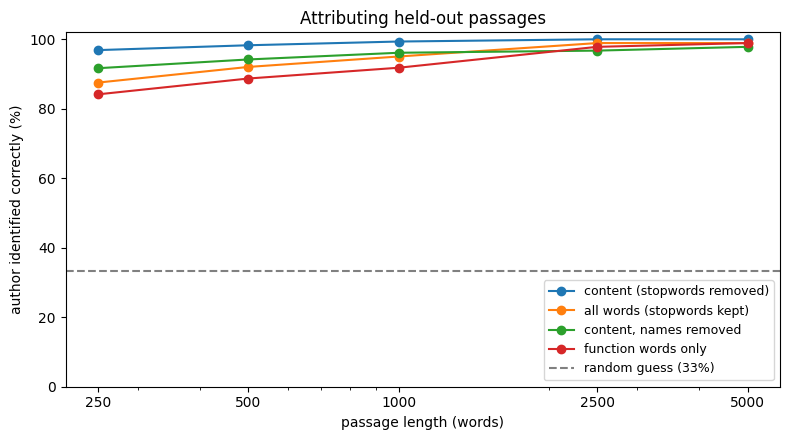

Accuracy by passage length:


,content (stopwords removed),all words (stopwords kept),"content, names removed",function words only
passage length (words),,,,
250,96.9,87.5,91.7,84.2
500,98.3,92.0,94.2,88.7
1000,99.4,95.0,96.1,91.8
2500,100.0,98.9,96.7,97.8
5000,100.0,98.9,97.8,98.9


Accuracy by book, 1,000-word passages:


,content (stopwords removed),all words (stopwords kept),"content, names removed",function words only
book,,,,
Pride and Prejudice,100.0,95.1,100.0,93.4
Emma,100.0,98.1,100.0,96.2
Huckleberry Finn,99.1,93.7,100.0,91.0
Tom Sawyer,97.2,90.1,74.6,80.3


In [13]:
PASSAGE_LENGTHS = [250, 500, 1000, 2500, 5000]


def attribute_passages(passage_len, view_name):
    """One row per passage: its book and whether the most similar OTHER book has the same author."""
    keep = VIEWS[view_name]
    books = {t: unit(profile(counts[t], total[t], keep)) for t in TITLES}   # normalize once for speed
    rows = []
    for t in TITLES:
        candidates = [b for b in TITLES if b != t]
        words = tokens[t]
        for start in range(0, len(words) - passage_len + 1, passage_len):
            passage = unit(profile(Counter(words[start:start + passage_len]), passage_len, keep))
            best = max(candidates, key=lambda b: sum(f * books[b].get(w, 0.0) for w, f in passage.items()))
            rows.append({"book": t, "correct": AUTHOR[best] == AUTHOR[t]})
    return pd.DataFrame(rows)


results = {(n, v): attribute_passages(n, v) for n in PASSAGE_LENGTHS for v in VIEWS}
accuracy = pd.DataFrame({v: [results[(n, v)]["correct"].mean() for n in PASSAGE_LENGTHS] for v in VIEWS},
                        index=pd.Index(PASSAGE_LENGTHS, name="passage length (words)"))

fig, ax = plt.subplots(figsize=(8, 4.5))
for v in VIEWS:
    ax.plot(accuracy.index, accuracy[v] * 100, marker="o", label=v)
ax.axhline(100 / 3, color="grey", linestyle="--", label="random guess (33%)")
ax.set_xscale("log")
ax.set_xticks(PASSAGE_LENGTHS)
ax.set_xticklabels(PASSAGE_LENGTHS)
ax.set_xlabel("passage length (words)")
ax.set_ylabel("author identified correctly (%)")
ax.set_ylim(0, 102)
ax.set_title("Attributing held-out passages")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

print("Accuracy by passage length:")
display((accuracy * 100).round(1))
print("Accuracy by book, 1,000-word passages:")
display(pd.DataFrame({v: results[(1000, v)].groupby("book")["correct"].mean() * 100 for v in VIEWS})
        .loc[TITLES].round(1))

- **Word frequencies work far better than chance.** With stopwords kept, about 95% of 1,000-word passages are attributed to the right author, and even 250-word passages (about one page) are right nearly 9 times in 10.
- **Content words score highest, but partly for the wrong reason.** *Tom Sawyer* passages drop from about 97% to about 75% correct once names are removed. Tom, Huck, Jim and Sid appear in both Twain books, so the method was partly recognizing *characters*, not the author.
- **Function words alone** carry no plot at all and still identify the author of most passages. That is the strongest evidence that there is a style fingerprint here.
- ***Tom Sawyer* is always the hardest book.** This matches the narrator effect seen in Q1.

## Extra credit: binomial test for single words

From the assignment: treat each word in a book as a trial, where "success" means the word is, e.g., *would*. Then p = N(would) / N(words), and a **two-proportion z-test** asks whether p is the same in two books. I tested *would* (the assignment's example), *could*, and *very*.

would: z would: p  could: z could: p  very: z   very: p
comparison        pair                                                                                    
same author       Pride & Prejudice vs Emma            -4.9  1.1e-06      -3.4  0.00067    -12.1   1.2e-33
                  Huck Finn vs Tom Sawyer               0.8     0.42       0.7     0.49     -1.4      0.17
different authors Pride & Prejudice vs Huck Finn        0.9     0.35       6.5    1e-10     14.9   1.6e-50
                  Pride & Prejudice vs Tom Sawyer       1.6      0.1       6.2  6.4e-10     11.3   7.7e-30
                  Emma vs Huck Finn                     5.7  1.2e-08       9.9  4.6e-23     24.6  3.7e-134
                  Emma vs Tom Sawyer                    5.6  1.8e-08       8.9  4.8e-19     19.2     3e-82

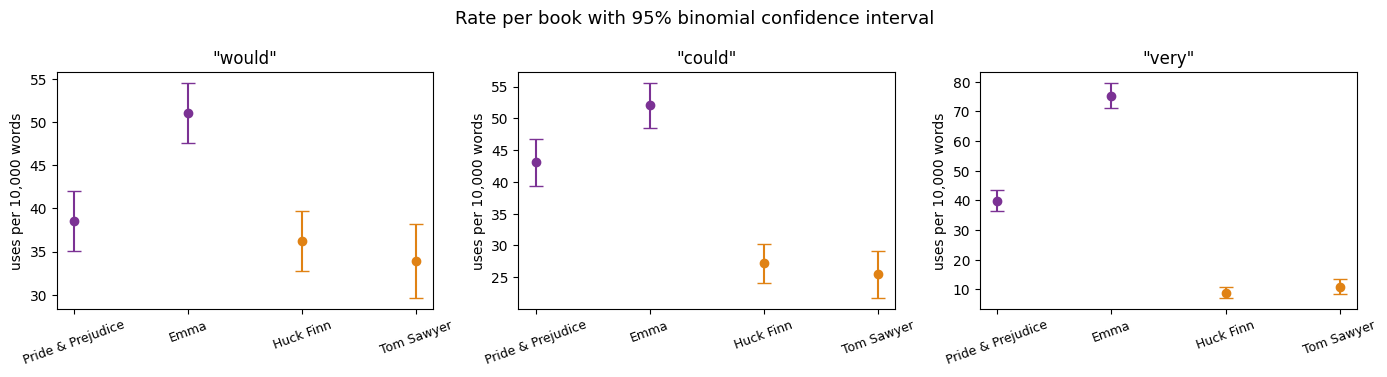

In [14]:
TEST_WORDS = ["would", "could", "very"]


def z_test(word, a, b):
    """Two-proportion z-test for the rate of `word` in books a and b. Returns (z, two-sided p-value)."""
    ka, kb, na, nb = counts[a][word], counts[b][word], total[a], total[b]
    pooled_p = (ka + kb) / (na + nb)
    z = (ka / na - kb / nb) / math.sqrt(pooled_p * (1 - pooled_p) * (1 / na + 1 / nb))
    return z, math.erfc(abs(z) / math.sqrt(2))


comparisons = [("same author", a, b) for a, b in [AUSTEN, TWAIN]] + \
              [("different authors", a, b) for a in AUSTEN for b in TWAIN]
rows = []
for kind, a, b in comparisons:
    row = {"comparison": kind, "pair": f"{SHORT[a]} vs {SHORT[b]}"}
    for word in TEST_WORDS:
        z, p = z_test(word, a, b)
        row[f"{word}: z"] = round(z, 1)
        row[f"{word}: p"] = f"{p:.2g}"
    rows.append(row)
display(pd.DataFrame(rows).set_index(["comparison", "pair"]))

# rates with 95% binomial confidence intervals
fig, axes = plt.subplots(1, len(TEST_WORDS), figsize=(14, 3.8))
for ax, word in zip(axes, TEST_WORDS):
    for i, t in enumerate(TITLES):
        p = counts[t][word] / total[t]
        ci = 1.96 * math.sqrt(p * (1 - p) / total[t])
        ax.errorbar(i, p * 10_000, yerr=ci * 10_000, fmt="o", capsize=5, color=COLOR[AUTHOR[t]])
    ax.set_xticks(range(4))
    ax.set_xticklabels([SHORT[t] for t in TITLES], rotation=20, fontsize=9)
    ax.set_title(f'"{word}"')
    ax.set_ylabel("uses per 10,000 words")
fig.suptitle("Rate per book with 95% binomial confidence interval", fontsize=13)
fig.tight_layout()
plt.show()

**Is the binomial model right?** If words were independent trials, the count of *would* in 1,000-word passages would have variance n·p·(1−p). A ratio above 1 means the real counts vary more than the model assumes, because words cluster in scenes and dialogue.

In [15]:
def variance_ratio(word, book, passage_len=1000):
    words = tokens[book]
    k = np.array([words[s:s + passage_len].count(word) for s in range(0, len(words) - passage_len + 1, passage_len)])
    p = k.mean() / passage_len
    return k.var(ddof=1) / (passage_len * p * (1 - p))


pd.DataFrame({word: {t: round(variance_ratio(word, t), 2) for t in TITLES} for word in TEST_WORDS})

,would,could,very
Pride and Prejudice,1.29,1.21,1.54
Emma,2.26,1.33,1.42
Huckleberry Finn,1.35,1.26,1.37
Tom Sawyer,2.30,1.49,1.75


- ***would* is not an author marker.** *Pride and Prejudice* and *Emma* differ significantly (p ≈ 10⁻⁶), yet *Pride and Prejudice* and *Huckleberry Finn* do **not** (p ≈ 0.35). A single word can differ more within an author than between authors.
- ***could* separates the authors cleanly**: |z| is 6-10 between authors but at most 3.4 within an author.
- ***very* is a huge between-author difference, but not a clean single-word test.** *Emma* uses it almost twice as often as *Pride and Prejudice*, so the Austen-vs-Austen z (about −12) is as extreme as one of the between-author comparisons.
- **Two cautions.** With 70,000-160,000 trials per book, almost any difference becomes "significant". And the variance ratios are above 1, so the binomial model underestimates the uncertainty and its p-values are too small. Effect sizes, consistency across books, and many words at once (as in Q1) are more trustworthy than a single-word significance test.

## Problems I encountered

1. **The license markers are not the book.** The current *Pride and Prejudice* file includes a multi-page preface by George Saintsbury plus illustration captions, and the Twain files include contents pages with chapter summaries. Without cutting at Chapter 1, another writer's words would have been counted as Austen's.
2. **Removing punctuation can create words.** Deleting apostrophes turns *he'll* into *hell* and *it's* into *its*. Keeping in-word apostrophes (and converting curly ’ to ') fixed it.
3. **Standard stopword lists don't fit these books.** NLTK's list lacks the modals *would, could, must, shall*. No list includes dialect grammar like *warn't, hain't, 'em*, so those land among the "content" words.
4. **Names and shared characters inflate similarity.** Tom, Huck, Jim and Sid appear in both Twain books. Removing capitalized words showed how much of the content signal came from characters.
5. **Topic and author are tangled.** Both Austen books are drawing-room courtship novels, and both Twain books are Mississippi boyhood stories. With this corpus I can't fully separate *who wrote it* from *what it's about*. Function words are the safest evidence because they carry the least topic.
6. **Narrative voice matters.** First-person dialect (*Huck Finn*) and third-person narration (*Tom Sawyer*) give the same author different fingerprints.
7. **Offensive language in the data.** A racial slur is frequent in *Huckleberry Finn*. It stays in the counts but is masked in all displayed output.

## Results

- **Q1:** Yes. In every view, each book is most similar to the other book by its author (e.g., all words: about 0.98 Austen-Austen and 0.94 Twain-Twain versus 0.85-0.89 across authors).
- **Q2:** Yes. Austen consistently prefers *whom, am, should, shall, very, must, not*, full forms like *cannot*, and *perhaps* and *suppose*. Twain prefers contractions, *maybe*, *reckon*, *mighty*, and words of movement (*up, down, out, around*).
- **Unseen passages:** word frequencies attribute about 95% of 1,000-word passages correctly (random guessing would get 33%), and function words alone do nearly as well.
- **Single-word tests:** *would* does not distinguish these authors. Binomial p-values overstate certainty because word counts are overdispersed.

## New ideas

- **Break the topic confound.** Add a Twain book with a different setting (*The Prince and the Pauper*, *A Connecticut Yankee in King Arthur's Court*) and an author of Austen's era who wrote similar novels (e.g., Frances Burney or Maria Edgeworth). Does the fingerprint follow the author or the subject?
- **Use a stylometry distance built for this.** Burrows' Delta z-scores the most frequent words so that *the* doesn't dominate the way it does with cosine similarity.
- **Try a real disputed-authorship case.** The *Federalist Papers* (Hamilton vs. Madison) were famously attributed with this kind of analysis, using function words such as *upon* and *whilst*.
- **Find the minimum document length.** Accuracy is still high at 250 words. How short can a text be (an email? a tweet?) before the method breaks down?